Loading Dataset

In [2]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('merged_asia_climate_weather.csv')

# View the first few rows of the data
df.head()

,record_id,country_code,country_name,region,income_level,date,year,month,week,latitude,...,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index,weather_temperature,weather_pm25,weather_pm10,humidity,rainfall,wind_speed
0,565,IND,India,South Asia,Lower-Middle,2015-01-04,2015,1,1,20.59,...,43.7,2470.0,69.9,87.9,22.351427,140.258652,183.088532,73.966532,0.164573,1.466963
1,566,IND,India,South Asia,Lower-Middle,2015-01-11,2015,1,2,20.59,...,45.2,2470.0,66.7,90.5,18.132758,153.122903,214.591338,76.154169,0.067611,1.708752
2,567,IND,India,South Asia,Lower-Middle,2015-01-18,2015,1,3,20.59,...,47.2,2470.0,68.8,97.3,18.678389,160.466244,228.289793,73.602345,0.083756,1.559631
3,568,IND,India,South Asia,Lower-Middle,2015-01-25,2015,1,4,20.59,...,46.7,2470.0,80.2,85.0,18.044618,143.600075,198.953801,77.282916,0.024873,1.561981
4,569,IND,India,South Asia,Lower-Middle,2015-02-01,2015,2,5,20.59,...,51.9,2474.0,72.9,93.1,17.872680,127.214510,175.572418,66.850582,0.121111,1.738562


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5076 entries, 0 to 5075
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     5076 non-null   int64  
 1   country_code                  5076 non-null   str    
 2   country_name                  5076 non-null   str    
 3   region                        5076 non-null   str    
 4   income_level                  5076 non-null   str    
 5   date                          5076 non-null   str    
 6   year                          5076 non-null   int64  
 7   month                         5076 non-null   int64  
 8   week                          5076 non-null   int64  
 9   latitude                      5076 non-null   float64
 10  longitude                     5076 non-null   float64
 11  population_millions           5076 non-null   int64  
 12  temperature_celsius           5076 non-null   float64
 13  temp_anomaly_c

In [4]:
# Returns the total count of null values in each column
df.isnull().sum()

record_id                       0
country_code                    0
country_name                    0
region                          0
income_level                    0
date                            0
year                            0
month                           0
week                            0
latitude                        0
longitude                       0
population_millions             0
temperature_celsius             0
temp_anomaly_celsius            0
precipitation_mm                0
heat_wave_days                  0
drought_indicator               0
flood_indicator                 0
extreme_weather_events          0
pm25_ugm3                       0
air_quality_index               0
respiratory_disease_rate        0
cardio_mortality_rate           0
vector_disease_risk_score       0
waterborne_disease_incidents    0
heat_related_admissions         0
healthcare_access_index         0
gdp_per_capita_usd              0
mental_health_index             0
food_security_

In [5]:
import pandas as pd

# 1. Ensure the data is sorted chronologically by country and date
df = df.sort_values(by=['country_code', 'date']).reset_index(drop=True)

# 2. Add columns for the previous 1 to 7 weeks
# (Using 'weather_pm25' as the air quality proxy; change to your specific AQI column if named differently)
for i in range(1, 8):
    df[f'pm25_lag_{i}_wk'] = df.groupby('country_code')['weather_pm25'].shift(i)

# View the original column alongside the 7 new lag columns
lag_cols = [f'pm25_lag_{i}_wk' for i in range(1, 8)]
df[['date', 'weather_pm25'] + lag_cols].head(10)

,date,weather_pm25,pm25_lag_1_wk,pm25_lag_2_wk,pm25_lag_3_wk,pm25_lag_4_wk,pm25_lag_5_wk,pm25_lag_6_wk,pm25_lag_7_wk
0,2015-01-04,140.258652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-11,153.122903,140.258652,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-18,160.466244,153.122903,140.258652,NaN,NaN,NaN,NaN,NaN
3,2015-01-25,143.600075,160.466244,153.122903,140.258652,NaN,NaN,NaN,NaN
4,2015-02-01,127.214510,143.600075,160.466244,153.122903,140.258652,NaN,NaN,NaN
5,2015-02-08,134.444095,127.214510,143.600075,160.466244,153.122903,140.258652,NaN,NaN
6,2015-02-15,140.308289,134.444095,127.214510,143.600075,160.466244,153.122903,140.258652,NaN
7,2015-02-22,115.845351,140.308289,134.444095,127.214510,143.600075,160.466244,153.122903,140.258652
8,2015-03-01,103.283862,115.845351,140.308289,134.444095,127.214510,143.600075,160.466244,153.122903
9,2015-03-08,95.647907,103.283862,115.845351,140.308289,134.444095,127.214510,143.600075,160.466244


In [6]:
df.head()

,record_id,country_code,country_name,region,income_level,date,year,month,week,latitude,...,humidity,rainfall,wind_speed,pm25_lag_1_wk,pm25_lag_2_wk,pm25_lag_3_wk,pm25_lag_4_wk,pm25_lag_5_wk,pm25_lag_6_wk,pm25_lag_7_wk
0,7897,BGD,Bangladesh,South Asia,Lower-Middle,2015-01-04,2015,1,1,23.68,...,73.966532,0.164573,1.466963,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7898,BGD,Bangladesh,South Asia,Lower-Middle,2015-01-11,2015,1,2,23.68,...,76.154169,0.067611,1.708752,140.258652,NaN,NaN,NaN,NaN,NaN,NaN
2,7899,BGD,Bangladesh,South Asia,Lower-Middle,2015-01-18,2015,1,3,23.68,...,73.602345,0.083756,1.559631,153.122903,140.258652,NaN,NaN,NaN,NaN,NaN
3,7900,BGD,Bangladesh,South Asia,Lower-Middle,2015-01-25,2015,1,4,23.68,...,77.282916,0.024873,1.561981,160.466244,153.122903,140.258652,NaN,NaN,NaN,NaN
4,7901,BGD,Bangladesh,South Asia,Lower-Middle,2015-02-01,2015,2,5,23.68,...,66.850582,0.121111,1.738562,143.600075,160.466244,153.122903,140.258652,NaN,NaN,NaN


In [7]:
import pandas as pd

# 1. Ensure the dataset is ordered chronologically by country and date
df = df.sort_values(by=['country_code', 'date']).reset_index(drop=True)

# 2. Generate 7 lag columns for temperature
for i in range(1, 8):
    df[f'temp_lag_{i}_wk'] = df.groupby('country_code')['weather_temperature'].shift(i)

# View original temperature alongside the 7 new lag columns
temp_lag_cols = [f'temp_lag_{i}_wk' for i in range(1, 8)]
df[['date', 'weather_temperature'] + temp_lag_cols].head(10)

df.head()

,record_id,country_code,country_name,region,income_level,date,year,month,week,latitude,...,pm25_lag_5_wk,pm25_lag_6_wk,pm25_lag_7_wk,temp_lag_1_wk,temp_lag_2_wk,temp_lag_3_wk,temp_lag_4_wk,temp_lag_5_wk,temp_lag_6_wk,temp_lag_7_wk
0,7897,BGD,Bangladesh,South Asia,Lower-Middle,2015-01-04,2015,1,1,23.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7898,BGD,Bangladesh,South Asia,Lower-Middle,2015-01-11,2015,1,2,23.68,...,NaN,NaN,NaN,22.351427,NaN,NaN,NaN,NaN,NaN,NaN
2,7899,BGD,Bangladesh,South Asia,Lower-Middle,2015-01-18,2015,1,3,23.68,...,NaN,NaN,NaN,18.132758,22.351427,NaN,NaN,NaN,NaN,NaN
3,7900,BGD,Bangladesh,South Asia,Lower-Middle,2015-01-25,2015,1,4,23.68,...,NaN,NaN,NaN,18.678389,18.132758,22.351427,NaN,NaN,NaN,NaN
4,7901,BGD,Bangladesh,South Asia,Lower-Middle,2015-02-01,2015,2,5,23.68,...,NaN,NaN,NaN,18.044618,18.678389,18.132758,22.351427,NaN,NaN,NaN


In [8]:
# Create 7-week lag features for air_quality_index
for i in range(1, 8):
    df[f'aqi_lag_{i}_wk'] = df.groupby('country_code')['air_quality_index'].shift(i)

In [9]:
df.head()
df.shape



(5076, 57)

In [10]:
df.head()

,record_id,country_code,country_name,region,income_level,date,year,month,week,latitude,...,temp_lag_5_wk,temp_lag_6_wk,temp_lag_7_wk,aqi_lag_1_wk,aqi_lag_2_wk,aqi_lag_3_wk,aqi_lag_4_wk,aqi_lag_5_wk,aqi_lag_6_wk,aqi_lag_7_wk
0,7897,BGD,Bangladesh,South Asia,Lower-Middle,2015-01-04,2015,1,1,23.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7898,BGD,Bangladesh,South Asia,Lower-Middle,2015-01-11,2015,1,2,23.68,...,NaN,NaN,NaN,194.0,NaN,NaN,NaN,NaN,NaN,NaN
2,7899,BGD,Bangladesh,South Asia,Lower-Middle,2015-01-18,2015,1,3,23.68,...,NaN,NaN,NaN,140.0,194.0,NaN,NaN,NaN,NaN,NaN
3,7900,BGD,Bangladesh,South Asia,Lower-Middle,2015-01-25,2015,1,4,23.68,...,NaN,NaN,NaN,99.0,140.0,194.0,NaN,NaN,NaN,NaN
4,7901,BGD,Bangladesh,South Asia,Lower-Middle,2015-02-01,2015,2,5,23.68,...,NaN,NaN,NaN,148.0,99.0,140.0,194.0,NaN,NaN,NaN


In [11]:
# Drop the first 7 rows (indices 0 through 6)
df = df.iloc[7:].reset_index(drop=True)

# Verify the new shape
print("Updated Shape:", df.shape)

Updated Shape: (5069, 57)


Identified Target Columns: ['heat_wave_days', 'respiratory_disease_rate', 'cardio_mortality_rate', 'heat_related_admissions']


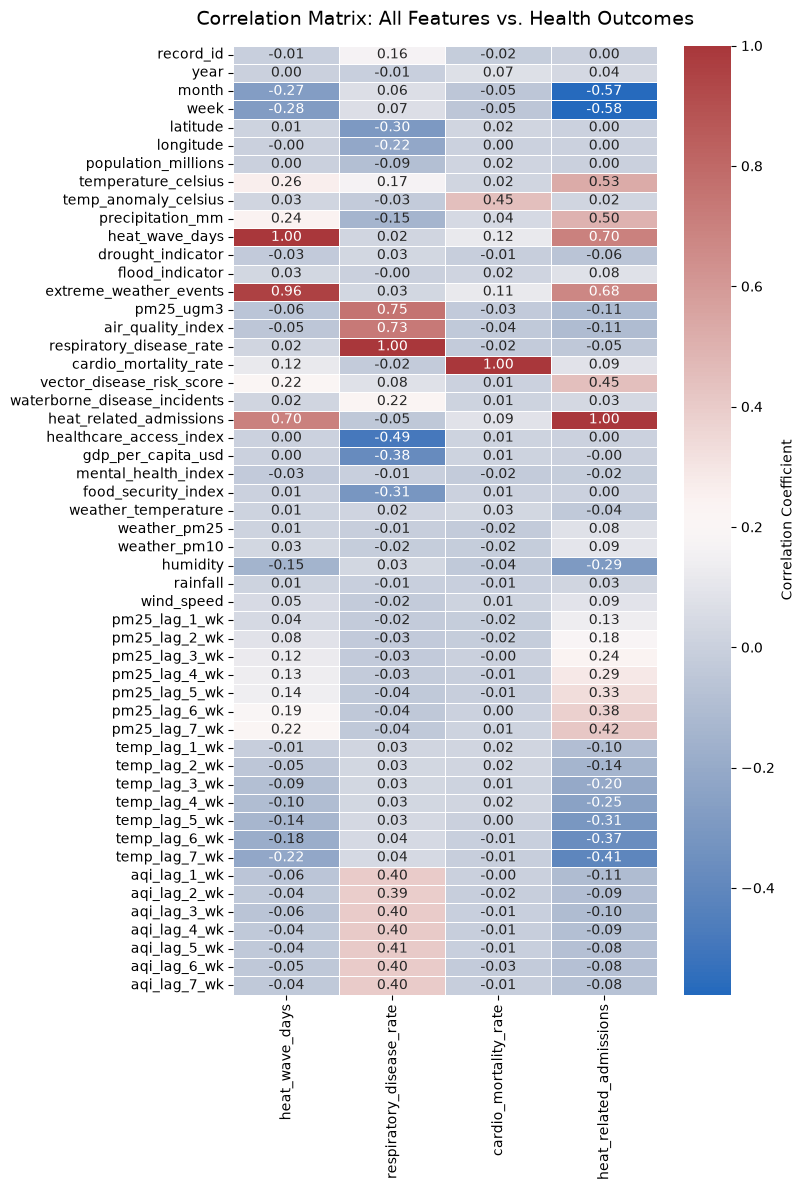

,heat_wave_days,respiratory_disease_rate,cardio_mortality_rate,heat_related_admissions
heat_wave_days,1.000000,0.021498,0.117251,0.702249
extreme_weather_events,0.962427,0.026781,0.113300,0.676445
heat_related_admissions,0.702249,-0.045259,0.087129,1.000000
temperature_celsius,0.262831,0.166200,0.024474,0.531670
precipitation_mm,0.243719,-0.145863,0.038827,0.497134
vector_disease_risk_score,0.218876,0.076998,0.005536,0.445649
pm25_lag_7_wk,0.217325,-0.040531,0.011692,0.418190
pm25_lag_6_wk,0.192824,-0.044773,0.002930,0.381464
pm25_lag_5_wk,0.142861,-0.040916,-0.011684,0.332221
pm25_lag_4_wk,0.134019,-0.025528,-0.012220,0.290343


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# First, double-check your exact target column names
target_cols = [col for col in df.columns if any(
    keyword in col.lower() for keyword in ['respiratory', 'cardio', 'heat']
)]

print("Identified Target Columns:", target_cols)

# Select only numerical columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

# Compute full correlation matrix and filter for target columns
corr_matrix = numeric_df.corr()
target_corr = corr_matrix[target_cols]

# --- 1. Display Visual Heatmap ---
plt.figure(figsize=(8, 12))
sns.heatmap(
    target_corr,
    annot=True,
    cmap='vlag',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix: All Features vs. Health Outcomes', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# --- 2. Display Sorted DataFrame View ---
# Display top correlations sorted by the first target variable
display(target_corr.sort_values(by=target_cols[0], ascending=False))

In [13]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Calculate full correlation matrix
full_corr = numeric_df.corr()

# Display styled interactive table in Jupyter Notebook
full_corr.style.background_gradient(cmap='coolwarm', axis=None).format("{:.2f}")

,record_id,year,month,week,latitude,longitude,population_millions,temperature_celsius,temp_anomaly_celsius,precipitation_mm,heat_wave_days,drought_indicator,flood_indicator,extreme_weather_events,pm25_ugm3,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index,weather_temperature,weather_pm25,weather_pm10,humidity,rainfall,wind_speed,pm25_lag_1_wk,pm25_lag_2_wk,pm25_lag_3_wk,pm25_lag_4_wk,pm25_lag_5_wk,pm25_lag_6_wk,pm25_lag_7_wk,temp_lag_1_wk,temp_lag_2_wk,temp_lag_3_wk,temp_lag_4_wk,temp_lag_5_wk,temp_lag_6_wk,temp_lag_7_wk,aqi_lag_1_wk,aqi_lag_2_wk,aqi_lag_3_wk,aqi_lag_4_wk,aqi_lag_5_wk,aqi_lag_6_wk,aqi_lag_7_wk
record_id,1.00,0.04,0.00,0.00,-0.53,0.14,-0.80,0.40,-0.01,0.02,-0.01,0.02,0.00,-0.00,0.20,0.20,0.16,-0.02,0.23,0.25,0.00,-0.53,-0.29,-0.01,-0.34,0.01,-0.01,-0.01,-0.00,-0.00,-0.00,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.20,0.20,0.20,0.20,0.20,0.20,0.20
year,0.04,1.00,-0.04,-0.04,0.00,-0.00,-0.00,0.02,0.13,0.02,0.00,0.01,-0.01,0.00,-0.00,-0.00,-0.01,0.07,0.02,-0.00,0.04,-0.01,0.03,-0.01,-0.01,0.15,-0.14,-0.14,-0.07,-0.10,-0.02,-0.13,-0.13,-0.12,-0.12,-0.12,-0.11,-0.11,0.14,0.13,0.13,0.12,0.12,0.12,0.12,-0.00,-0.00,-0.01,-0.01,-0.01,-0.01,-0.01
month,0.00,-0.04,1.00,0.95,0.00,-0.00,-0.00,-0.50,-0.01,-0.54,-0.27,0.08,-0.06,-0.25,0.11,0.10,0.06,-0.05,-0.34,-0.02,-0.57,-0.00,0.00,-0.00,-0.02,0.14,-0.14,-0.15,0.24,-0.08,-0.10,-0.23,-0.30,-0.37,-0.41,-0.45,-0.50,-0.52,0.23,0.32,0.39,0.45,0.50,0.51,0.52,0.11,0.10,0.10,0.09,0.09,0.09,0.09
week,0.00,-0.04,0.95,1.00,0.00,-0.00,-0.00,-0.50,-0.00,-0.53,-0.28,0.09,-0.06,-0.26,0.11,0.10,0.07,-0.05,-0.35,-0.02,-0.58,-0.00,0.00,-0.01,-0.02,0.12,-0.12,-0.12,0.25,-0.08,-0.11,-0.19,-0.26,-0.33,-0.38,-0.44,-0.49,-0.51,0.18,0.27,0.35,0.41,0.49,0.51,0.51,0.10,0.10,0.09,0.10,0.09,0.09,0.08
latitude,-0.53,0.00,0.00,0.00,1.00,-0.10,0.32,-0.74,0.01,0.00,0.01,-0.01,0.01,0.01,-0.37,-0.36,-0.30,0.02,-0.54,-0.34,0.00,0.68,0.52,0.00,0.43,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.36,-0.36,-0.36,-0.36,-0.36,-0.36,-0.36
longitude,0.14,-0.00,-0.00,-0.00,-0.10,1.00,-0.33,0.07,0.00,-0.01,-0.00,0.01,-0.04,-0.01,-0.29,-0.28,-0.22,0.00,0.18,-0.18,0.00,0.32,0.63,-0.00,0.18,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.28,-0.28,-0.28,-0.28,-0.28,-0.28,-0.28
population_millions,-0.80,-0.00,-0.00,-0.00,0.32,-0.33,1.00,-0.24,0.02,-0.02,0.00,-0.01,-0.00,-0.00,-0.10,-0.10,-0.09,0.02,-0.17,-0.11,0.00,0.26,-0.16,0.01,0.17,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.10,-0.10,-0.10,-0.10,-0.10,-0.10,-0.10
temperature_celsius,0.40,0.02,-0.50,-0.50,-0.74,0.07,-0.24,1.00,-0.00,0.43,0.26,-0.05,0.05,0.25,0.18,0.18,0.17,0.02,0.72,0.28,0.53,-0.51,-0.39,-0.01,-0.32,-0.11,0.11,0.12,-0.20,-0.01,0.10,0.16,0.20,0.23,0.27,0.30,0.33,0.35,-0.14,-0.18,-0.22,-0.25,-0.28,-0.31,-0.33,0.18,0.18,0.18,0.18,0.19,0.20,0.20
temp_anomaly_celsius,-0.01,0.13,-0.01,-0.00,0.01,0.00,0.02,-0.00,1.00,-0.00,0.03,-0.01,0.01,0.02,-0.02,-0.02,-0.03,0.45,-0.00,0.01,0.02,0.00,0.00,-0.02,0.01,0.02,-0.02,-0.02,-0.03,-0.01,-0.00,-0.01,-0.02,-0.01,-0.01,-0.02,-0.02,-0.02,0.01,0.02,0.02,0.01,0.01,-0.00,0.01,0.00,0.00,-0.00,-0.02,-0.00,-0.01,-0.01
precipitation_mm,0.02,0.02,-0.54,-0.53,0.00,-0.01,-0.02,0.43,-0.00,1.00,0.24,-0.17,0.16,0.22,-0.20,-0.19,-0.15,0.04,0.33,0.07,0.50,-0.01,-0.00,-0.01,0.01,-0.12,0.13,0.13,-0.22,-0.01,0.09,0.18,0.22,0.26,0.30,0.34,0.35,0.38,-0.17,-0.21,-0.24,-0.28,-0.31,-0.34,-0.36,-0.08,-0.09,-0.09,-0.08,-0.08,-0.07,-0.06


,healthcare_access_index,gdp_per_capita_usd,food_security_index,vector_disease_risk_score,waterborne_disease_incidents,mental_health_index
healthcare_access_index,1.0000,0.7849,0.6188,-0.2634,-0.4929,0.0075
gdp_per_capita_usd,0.7849,1.0000,0.4860,-0.1912,-0.4083,0.0042
food_security_index,0.6188,0.4860,1.0000,-0.1545,-0.3653,0.0415
vector_disease_risk_score,-0.2634,-0.1912,-0.1545,1.0000,0.1353,-0.0180
waterborne_disease_incidents,-0.4929,-0.4083,-0.3653,0.1353,1.0000,-0.0431
mental_health_index,0.0075,0.0042,0.0415,-0.0180,-0.0431,1.0000


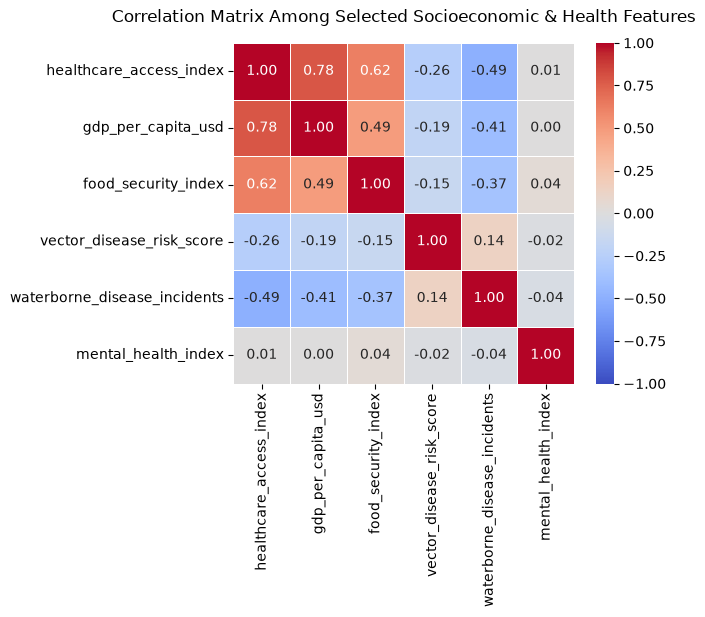

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the 6 specific features
selected_features = [
    'healthcare_access_index',
    'gdp_per_capita_usd',
    'food_security_index',
    'vector_disease_risk_score',
    'waterborne_disease_incidents',
    'mental_health_index'
]

# 2. Compute correlation matrix among these 6 features
feature_corr = df[selected_features].corr()

# --- Option A: Interactive Styled Table ---
display(feature_corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format("{:.4f}"))

# --- Option B: Visual Heatmap Plot ---
plt.figure(figsize=(7, 6))
sns.heatmap(
    feature_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix Among Selected Socioeconomic & Health Features', pad=15)
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Ensure the date column is a proper datetime object
df['date'] = pd.to_datetime(df['date'])

# ---------------------------------------------------------
# Step 1: Smart Outlier Handling (Grouped Rolling Median)
# ---------------------------------------------------------
def cap_outliers_rolling(series, window=5):
    # Calculate a rolling median (centers on the current week)
    rolling_median = series.rolling(window=window, center=True, min_periods=1).median()

    # Calculate a dynamic bound (e.g., median +/- 3 standard deviations)
    std_dev = series.std()
    upper_bound = rolling_median + (3 * std_dev)
    lower_bound = rolling_median - (3 * std_dev)

    # Cap the extreme outliers without dropping chronological rows
    return series.clip(lower=lower_bound, upper=upper_bound)

# Apply this to volatile weather/climate columns, grouped strictly by country
outlier_cols = ['weather_pm25', 'weather_pm10', 'weather_temperature']
for col in outlier_cols:
    df[col] = df.groupby('country_code')[col].transform(cap_outliers_rolling)

# ---------------------------------------------------------
# Step 2: Cyclical Encoding for Time Variables
# ---------------------------------------------------------
# Create sine and cosine features for months (12) and weeks (52)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)

# ---------------------------------------------------------
# Step 3: Strict Chronological Splitting
# ---------------------------------------------------------
# Set a cutoff date (adjust the year based on your specific dataset timeline)
split_date = '2019-01-01'

train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

# ---------------------------------------------------------
# Step 4: Feature Scaling
# ---------------------------------------------------------
# List numerical features to scale.
# Do NOT scale IDs, targets (like heat_wave_days), or the new cyclical time features.
features_to_scale = [
    'weather_temperature', 'weather_pm25', 'weather_pm10',
    'humidity', 'rainfall', 'wind_speed', 'gdp_per_capita_usd'
]

scaler = StandardScaler()

# Fit the scaler ONLY on the training data
train_df[features_to_scale] = scaler.fit_transform(train_df[features_to_scale])

# Transform the test data using the fitted scaler
test_df[features_to_scale] = scaler.transform(test_df[features_to_scale])

# Now your train_df and test_df are ready for sequence generation!

In [16]:
import numpy as np

# 1. Define your targets based on the DL notebook
target_cols = ['respiratory_disease_rate', 'cardio_mortality_rate', 'heat_related_admissions']

# 2. Define columns to ignore (IDs, text, and the raw dates we replaced)
cols_to_drop = ['record_id', 'country_name', 'region', 'income_level', 'date', 'year', 'month', 'week']

def create_sequences(data, target_columns, drop_columns, time_steps=7):
    X, y = [], []

    # Group by country to prevent data mixing
    for country, group in data.groupby('country_code'):

        # Drop the non-predictive columns and isolate targets
        # Note: 'country_code' is also dropped here so it doesn't feed into the math
        features = group.drop(columns=drop_columns + target_columns + ['country_code']).values
        labels = group[target_columns].values

        # Slide a 7-week window across the group's data
        for i in range(len(group) - time_steps):
            X.append(features[i:i + time_steps]) # The past 7 weeks
            y.append(labels[i + time_steps])     # The target for the 8th week

    return np.array(X), np.array(y)

# 3. Generate the 3D sequences for both Train and Test sets
X_train, y_train = create_sequences(train_df, target_cols, cols_to_drop, time_steps=7)
X_test, y_test = create_sequences(test_df, target_cols, cols_to_drop, time_steps=7)

print("Training Features Shape:", X_train.shape)
print("Training Targets Shape:", y_train.shape)

# 4. Save the sequences to the .npz file your second notebook expects
np.savez('lstm_processed_sequences.npz',
         X_train=X_train,
         y_train=y_train,
         X_test=X_test,
         y_test=y_test)

print("New sequences successfully saved to 'lstm_processed_sequences.npz'!")

Training Features Shape: (1811, 7, 49)
Training Targets Shape: (1811, 3)
New sequences successfully saved to 'lstm_processed_sequences.npz'!


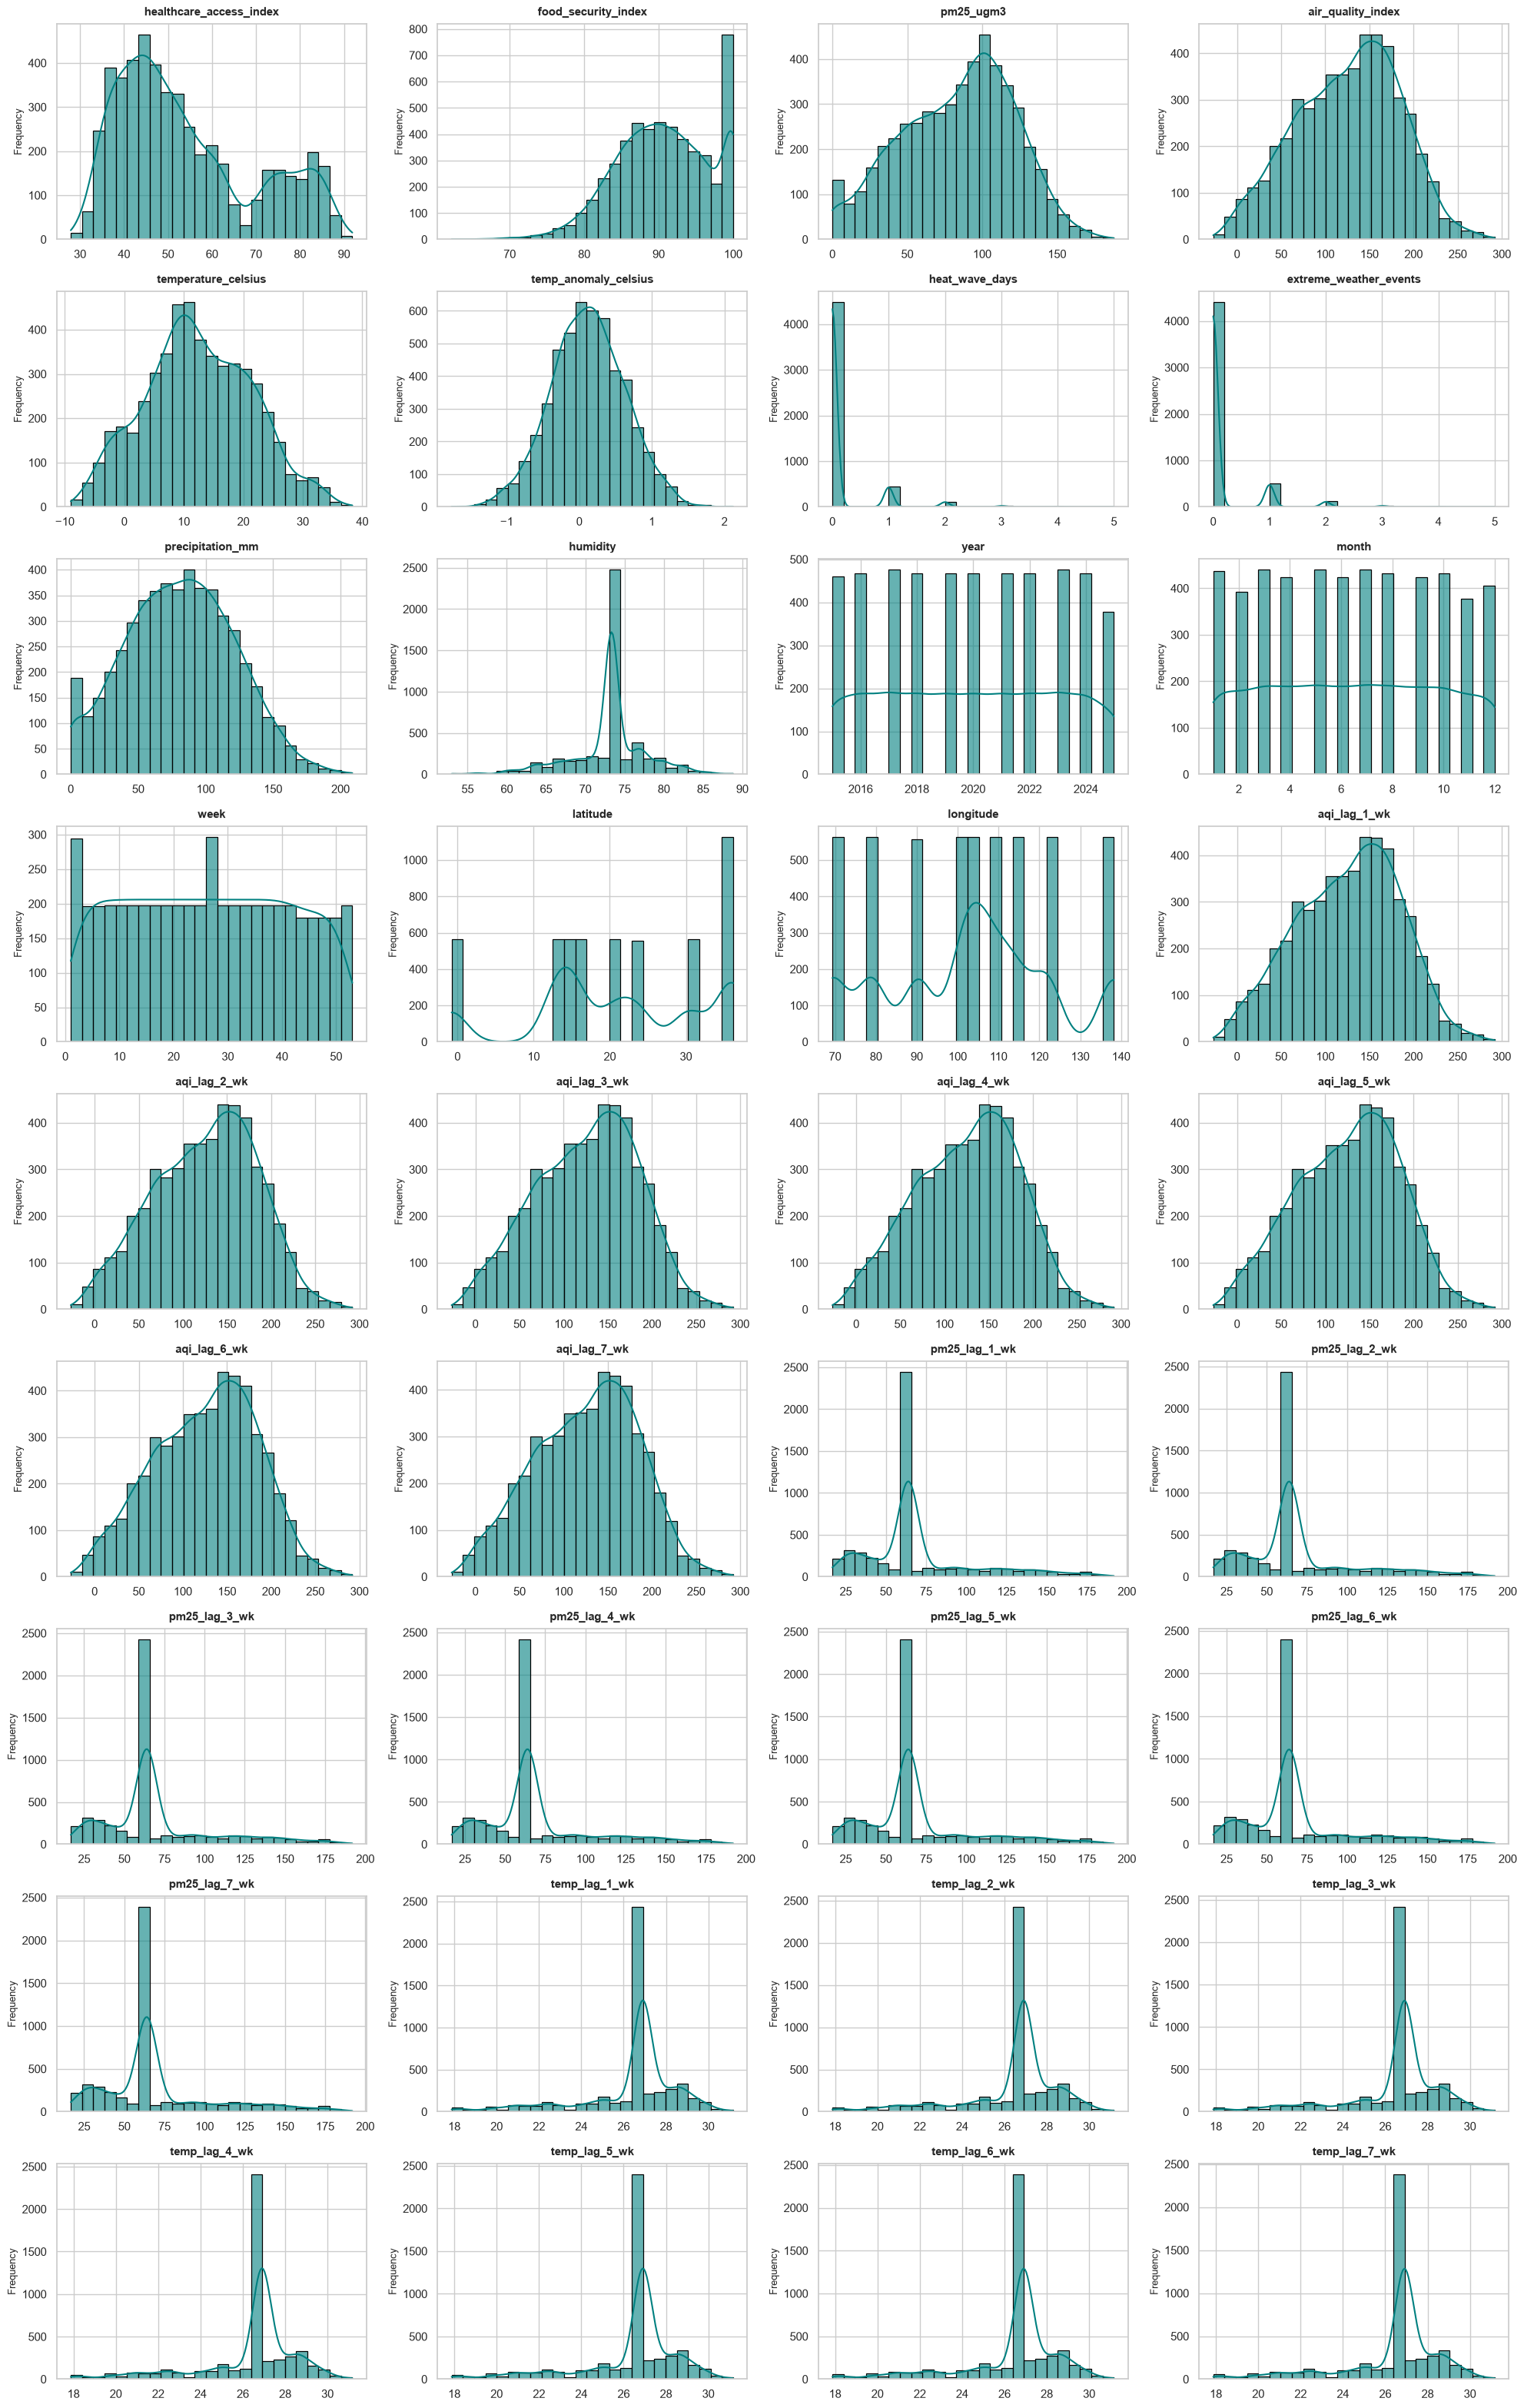

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Define your finalized input feature matrix X
X = df[[
    # Selected Socioeconomic Pair
    'healthcare_access_index', 'food_security_index',

    # Meteorological & Environmental Base Features
    'pm25_ugm3', 'air_quality_index', 'temperature_celsius',
    'temp_anomaly_celsius', 'heat_wave_days', 'extreme_weather_events',
    'precipitation_mm', 'humidity',

    # Spatial & Temporal Identifiers
    'year', 'month', 'week', 'latitude', 'longitude',

    # All 21 Lagged Features (AQI, PM2.5, Temperature across 7 weeks)
    'aqi_lag_1_wk', 'aqi_lag_2_wk', 'aqi_lag_3_wk', 'aqi_lag_4_wk', 'aqi_lag_5_wk', 'aqi_lag_6_wk', 'aqi_lag_7_wk',
    'pm25_lag_1_wk', 'pm25_lag_2_wk', 'pm25_lag_3_wk', 'pm25_lag_4_wk', 'pm25_lag_5_wk', 'pm25_lag_6_wk', 'pm25_lag_7_wk',
    'temp_lag_1_wk', 'temp_lag_2_wk', 'temp_lag_3_wk', 'temp_lag_4_wk', 'temp_lag_5_wk', 'temp_lag_6_wk', 'temp_lag_7_wk'
]]

# 2. Set up dynamic grid dimensions
features = X.columns
n_cols = 4  # 4 plots per row
n_rows = math.ceil(len(features) / n_cols)

# 3. Create grid of subplots
plt.figure(figsize=(20, n_rows * 3.5))
sns.set_theme(style="whitegrid")

for i, col in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(X[col], kde=True, color='teal', bins=25, edgecolor='black', alpha=0.6)
    plt.title(col, fontsize=11, fontweight='bold', pad=8)
    plt.xlabel('')
    plt.ylabel('Frequency', fontsize=9)

plt.tight_layout()
plt.show()

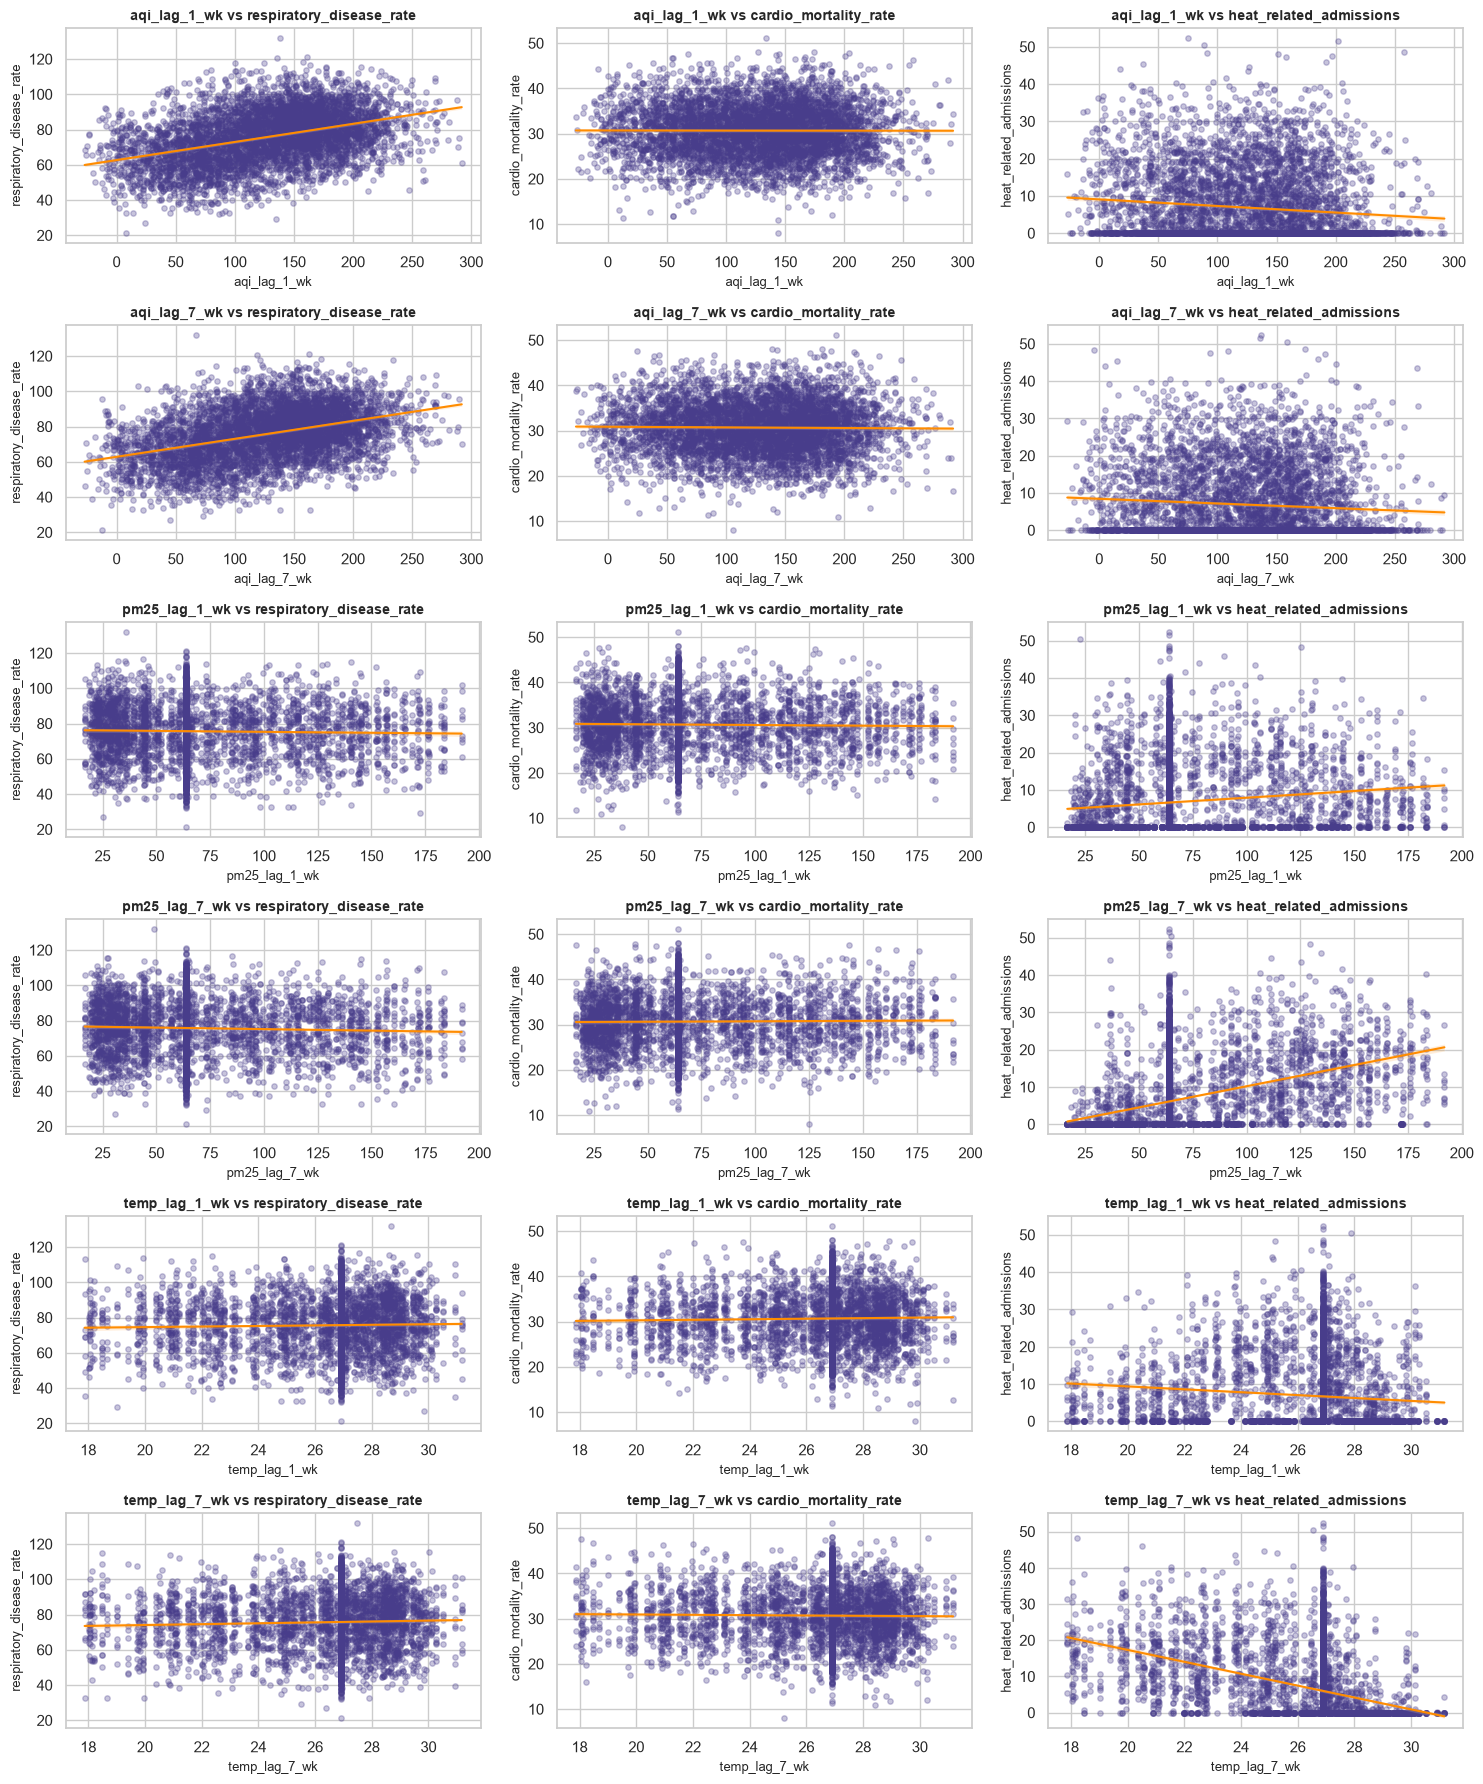

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Explicitly define targets and lag features
targets = [
    'respiratory_disease_rate',
    'cardio_mortality_rate',
    'heat_related_admissions'
]

lag_features = [
    'aqi_lag_1_wk', 'aqi_lag_7_wk',
    'pm25_lag_1_wk', 'pm25_lag_7_wk',
    'temp_lag_1_wk', 'temp_lag_7_wk'
]

# 2. Plot lag features vs target outputs
fig, axes = plt.subplots(nrows=len(lag_features), ncols=len(targets), figsize=(15, len(lag_features) * 3))

sns.set_theme(style="whitegrid")

for i, lag_col in enumerate(lag_features):
    for j, target in enumerate(targets):
        ax = axes[i, j]
        sns.regplot(
            data=df,
            x=lag_col,
            y=target,
            ax=ax,
            scatter_kws={'alpha': 0.3, 'color': 'darkslateblue', 's': 15},
            line_kws={'color': 'darkorange', 'linewidth': 1.5}
        )
        ax.set_title(f'{lag_col} vs {target}', fontsize=10, fontweight='bold')
        ax.set_xlabel(lag_col, fontsize=9)
        ax.set_ylabel(target, fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
df.head()

,record_id,country_code,country_name,region,income_level,date,year,month,week,latitude,...,aqi_lag_2_wk,aqi_lag_3_wk,aqi_lag_4_wk,aqi_lag_5_wk,aqi_lag_6_wk,aqi_lag_7_wk,month_sin,month_cos,week_sin,week_cos
0,7904,BGD,Bangladesh,South Asia,Lower-Middle,2015-02-22,2015,2,8,23.68,...,99.0,184.0,148.0,99.0,140.0,194.0,0.866025,5.000000e-01,0.822984,0.568065
1,7905,BGD,Bangladesh,South Asia,Lower-Middle,2015-03-01,2015,3,9,23.68,...,125.0,99.0,184.0,148.0,99.0,140.0,1.000000,6.123234e-17,0.885456,0.464723
2,7906,BGD,Bangladesh,South Asia,Lower-Middle,2015-03-08,2015,3,10,23.68,...,65.0,125.0,99.0,184.0,148.0,99.0,1.000000,6.123234e-17,0.935016,0.354605
3,7907,BGD,Bangladesh,South Asia,Lower-Middle,2015-03-15,2015,3,11,23.68,...,123.0,65.0,125.0,99.0,184.0,148.0,1.000000,6.123234e-17,0.970942,0.239316
4,7908,BGD,Bangladesh,South Asia,Lower-Middle,2015-03-22,2015,3,12,23.68,...,132.0,123.0,65.0,125.0,99.0,184.0,1.000000,6.123234e-17,0.992709,0.120537


In [20]:
# Linear Regression without Lag

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Define input feature matrix WITHOUT any lag features
X_no_lags = df[[
    # Selected Socioeconomic Pair
    'healthcare_access_index', 'food_security_index',

    # Meteorological & Environmental Base Features
    'pm25_ugm3', 'air_quality_index', 'temperature_celsius',
    'temp_anomaly_celsius', 'heat_wave_days', 'extreme_weather_events',
    'precipitation_mm', 'humidity',

    # Spatial & Temporal Identifiers
    'year', 'month', 'week', 'latitude', 'longitude'
]]

# Drop any remaining missing values in features or targets
clean_df = df.dropna(subset=X_no_lags.columns.tolist() + [
    'respiratory_disease_rate', 'cardio_mortality_rate', 'heat_related_admissions'
]).reset_index(drop=True)

X_no_lags = clean_df[X_no_lags.columns]

# Define target matrices
targets = {
    'Respiratory Disease Rate': clean_df['respiratory_disease_rate'],
    'Cardio Mortality Rate': clean_df['cardio_mortality_rate'],
    'Heat-Related Admissions': clean_df['heat_related_admissions']
}

# 2. Train and evaluate Linear Regression for each target output
models = {}
results = []

for target_name, y in targets.items():
    # Split data (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_no_lags, y, test_size=0.2, random_state=42
    )

    # Initialize and train Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    models[target_name] = model

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate performance metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'Target Outcome': target_name,
        'R² Score': round(r2, 4),
        'MSE': round(mse, 4),
        'MAE': round(mae, 4)
    })

# 3. Display summary evaluation table
results_df = pd.DataFrame(results)
display(results_df.style.background_gradient(subset=['R² Score'], cmap='viridis'))

,Target Outcome,R² Score,MSE,MAE
0,Respiratory Disease Rate,0.570000,94.712600,7.794100
1,Cardio Mortality Rate,0.202700,25.114600,3.973000
2,Heat-Related Admissions,0.805900,18.057600,3.281000


In [21]:
#Linear Regression with lag

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Define input feature matrix WITH all 21 lag features
X_with_lags = df[[
    # Selected Socioeconomic Pair
    'healthcare_access_index', 'food_security_index',

    # Meteorological & Environmental Base Features
    'pm25_ugm3', 'air_quality_index', 'temperature_celsius',
    'temp_anomaly_celsius', 'heat_wave_days', 'extreme_weather_events',
    'precipitation_mm', 'humidity',

    # Spatial & Temporal Identifiers
    'year', 'month', 'week', 'latitude', 'longitude',

    # All 21 Lagged Features (AQI, PM2.5, Temperature across 7 weeks)
    'aqi_lag_1_wk', 'aqi_lag_2_wk', 'aqi_lag_3_wk', 'aqi_lag_4_wk', 'aqi_lag_5_wk', 'aqi_lag_6_wk', 'aqi_lag_7_wk',
    'pm25_lag_1_wk', 'pm25_lag_2_wk', 'pm25_lag_3_wk', 'pm25_lag_4_wk', 'pm25_lag_5_wk', 'pm25_lag_6_wk', 'pm25_lag_7_wk',
    'temp_lag_1_wk', 'temp_lag_2_wk', 'temp_lag_3_wk', 'temp_lag_4_wk', 'temp_lag_5_wk', 'temp_lag_6_wk', 'temp_lag_7_wk'
]]

# Drop rows with NaNs resulting from lag creation
clean_df_lags = df.dropna(subset=X_with_lags.columns.tolist() + [
    'respiratory_disease_rate', 'cardio_mortality_rate', 'heat_related_admissions'
]).reset_index(drop=True)

X_with_lags = clean_df_lags[X_with_lags.columns]

# Define targets
targets_lags = {
    'Respiratory Disease Rate': clean_df_lags['respiratory_disease_rate'],
    'Cardio Mortality Rate': clean_df_lags['cardio_mortality_rate'],
    'Heat-Related Admissions': clean_df_lags['heat_related_admissions']
}

# 2. Train and evaluate Linear Regression with lag features
models_lags = {}
results_lags = []

for target_name, y in targets_lags.items():
    # Split data (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_with_lags, y, test_size=0.2, random_state=42
    )

    # Initialize and train Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    models_lags[target_name] = model

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate performance metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results_lags.append({
        'Target Outcome': target_name,
        'R² Score (With Lags)': round(r2, 4),
        'MSE': round(mse, 4),
        'MAE': round(mae, 4)
    })

# 3. Display summary evaluation table
results_lags_df = pd.DataFrame(results_lags)
display(results_lags_df.style.background_gradient(subset=['R² Score (With Lags)'], cmap='viridis'))

,Target Outcome,R² Score (With Lags),MSE,MAE
0,Respiratory Disease Rate,0.548300,101.950000,8.091200
1,Cardio Mortality Rate,0.208000,25.141900,4.004800
2,Heat-Related Admissions,0.824400,16.861800,3.134900


In [22]:
#Random Forest Without Lag

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Define input feature matrix WITHOUT lag features
X_no_lags = df[[
    # Selected Socioeconomic Pair
    'healthcare_access_index', 'food_security_index',

    # Meteorological & Environmental Base Features
    'pm25_ugm3', 'air_quality_index', 'temperature_celsius',
    'temp_anomaly_celsius', 'heat_wave_days', 'extreme_weather_events',
    'precipitation_mm', 'humidity',

    # Spatial & Temporal Identifiers
    'year', 'month', 'week', 'latitude', 'longitude'
]]

# Drop rows with NaNs in features or targets
clean_df_rf_no_lags = df.dropna(subset=X_no_lags.columns.tolist() + [
    'respiratory_disease_rate', 'cardio_mortality_rate', 'heat_related_admissions'
]).reset_index(drop=True)

X_rf_no_lags = clean_df_rf_no_lags[X_no_lags.columns]

# Define targets
targets_rf_no_lags = {
    'Respiratory Disease Rate': clean_df_rf_no_lags['respiratory_disease_rate'],
    'Cardio Mortality Rate': clean_df_rf_no_lags['cardio_mortality_rate'],
    'Heat-Related Admissions': clean_df_rf_no_lags['heat_related_admissions']
}

# 2. Train and evaluate Random Forest Regressor (No Lags)
rf_no_lags_models = {}
rf_no_lags_results = []

for target_name, y in targets_rf_no_lags.items():
    # Split data (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_rf_no_lags, y, test_size=0.2, random_state=42
    )

    # Initialize and train Random Forest
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    rf_no_lags_models[target_name] = rf_model

    # Make predictions
    y_pred = rf_model.predict(X_test)

    # Calculate performance metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    rf_no_lags_results.append({
        'Target Outcome': target_name,
        'RF R² (No Lags)': round(r2, 4),
        'RF MSE': round(mse, 4),
        'RF MAE': round(mae, 4)
    })

# 3. Display summary evaluation table
rf_no_lags_df = pd.DataFrame(rf_no_lags_results)
display(rf_no_lags_df.style.background_gradient(subset=['RF R² (No Lags)'], cmap='viridis'))

,Target Outcome,RF R² (No Lags),RF MSE,RF MAE
0,Respiratory Disease Rate,0.532300,103.000900,8.120600
1,Cardio Mortality Rate,0.152500,26.697300,4.096500
2,Heat-Related Admissions,0.812300,17.461400,2.645800


In [23]:
#Random Forest With Lag

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Define input feature matrix WITH all 21 lag features
X_with_lags = df[[
    # Selected Socioeconomic Pair
    'healthcare_access_index', 'food_security_index',

    # Meteorological & Environmental Base Features
    'pm25_ugm3', 'air_quality_index', 'temperature_celsius',
    'temp_anomaly_celsius', 'heat_wave_days', 'extreme_weather_events',
    'precipitation_mm', 'humidity',

    # Spatial & Temporal Identifiers
    'year', 'month', 'week', 'latitude', 'longitude',

    # All 21 Lagged Features (AQI, PM2.5, Temperature across 7 weeks)
    'aqi_lag_1_wk', 'aqi_lag_2_wk', 'aqi_lag_3_wk', 'aqi_lag_4_wk', 'aqi_lag_5_wk', 'aqi_lag_6_wk', 'aqi_lag_7_wk',
    'pm25_lag_1_wk', 'pm25_lag_2_wk', 'pm25_lag_3_wk', 'pm25_lag_4_wk', 'pm25_lag_5_wk', 'pm25_lag_6_wk', 'pm25_lag_7_wk',
    'temp_lag_1_wk', 'temp_lag_2_wk', 'temp_lag_3_wk', 'temp_lag_4_wk', 'temp_lag_5_wk', 'temp_lag_6_wk', 'temp_lag_7_wk'
]]

# Drop rows with NaNs resulting from lag creation
clean_df_rf = df.dropna(subset=X_with_lags.columns.tolist() + [
    'respiratory_disease_rate', 'cardio_mortality_rate', 'heat_related_admissions'
]).reset_index(drop=True)

X_rf = clean_df_rf[X_with_lags.columns]

# Define targets
targets_rf = {
    'Respiratory Disease Rate': clean_df_rf['respiratory_disease_rate'],
    'Cardio Mortality Rate': clean_df_rf['cardio_mortality_rate'],
    'Heat-Related Admissions': clean_df_rf['heat_related_admissions']
}

# 2. Train and evaluate Random Forest Regressor for each target
rf_models = {}
rf_results = []

for target_name, y in targets_rf.items():
    # Split data (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_rf, y, test_size=0.2, random_state=42
    )

    # Initialize and train Random Forest
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    rf_models[target_name] = rf_model

    # Make predictions
    y_pred = rf_model.predict(X_test)

    # Calculate performance metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    rf_results.append({
        'Target Outcome': target_name,
        'RF R² Score': round(r2, 4),
        'RF MSE': round(mse, 4),
        'RF MAE': round(mae, 4)
    })

# 3. Display summary evaluation table
rf_results_df = pd.DataFrame(rf_results)
display(rf_results_df.style.background_gradient(subset=['RF R² Score'], cmap='viridis'))

,Target Outcome,RF R² Score,RF MSE,RF MAE
0,Respiratory Disease Rate,0.536500,104.613000,8.195300
1,Cardio Mortality Rate,0.153700,26.863500,4.149400
2,Heat-Related Admissions,0.834900,15.856200,2.544900


In [24]:
# XG boost without lag

import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Define input feature matrix WITHOUT lag features
X_no_lags = df[[
    # Selected Socioeconomic Pair
    'healthcare_access_index', 'food_security_index',

    # Meteorological & Environmental Base Features
    'pm25_ugm3', 'air_quality_index', 'temperature_celsius',
    'temp_anomaly_celsius', 'heat_wave_days', 'extreme_weather_events',
    'precipitation_mm', 'humidity',

    # Spatial & Temporal Identifiers
    'year', 'month', 'week', 'latitude', 'longitude'
]]

# Drop rows with NaNs in features or targets
clean_df_xgb_no_lags = df.dropna(subset=X_no_lags.columns.tolist() + [
    'respiratory_disease_rate', 'cardio_mortality_rate', 'heat_related_admissions'
]).reset_index(drop=True)

X_xgb_no_lags = clean_df_xgb_no_lags[X_no_lags.columns]

# Define targets
targets_xgb = {
    'Respiratory Disease Rate': clean_df_xgb_no_lags['respiratory_disease_rate'],
    'Cardio Mortality Rate': clean_df_xgb_no_lags['cardio_mortality_rate'],
    'Heat-Related Admissions': clean_df_xgb_no_lags['heat_related_admissions']
}

# 2. Train and evaluate XGBoost Regressor (No Lags)
xgb_no_lags_models = {}
xgb_no_lags_results = []

for target_name, y in targets_xgb.items():
    # Split data (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_xgb_no_lags, y, test_size=0.2, random_state=42
    )

    # Initialize and train XGBoost Regressor
    xgb_model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    xgb_no_lags_models[target_name] = xgb_model

    # Make predictions
    y_pred = xgb_model.predict(X_test)

    # Calculate performance metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    xgb_no_lags_results.append({
        'Target Outcome': target_name,
        'XGBoost R² (No Lags)': round(r2, 4),
        'XGB MSE': round(mse, 4),
        'XGB MAE': round(mae, 4)
    })

# 3. Display summary evaluation table
xgb_no_lags_df = pd.DataFrame(xgb_no_lags_results)
display(xgb_no_lags_df.style.background_gradient(subset=['XGBoost R² (No Lags)'], cmap='viridis'))

,Target Outcome,XGBoost R² (No Lags),XGB MSE,XGB MAE
0,Respiratory Disease Rate,0.538700,101.591900,8.023400
1,Cardio Mortality Rate,0.161000,26.426600,4.092200
2,Heat-Related Admissions,0.826900,16.108200,2.550500


In [25]:
#xgboost with lag

import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Define input feature matrix WITH all 21 lag features
X_with_lags = df[[
    # Selected Socioeconomic Pair
    'healthcare_access_index', 'food_security_index',

    # Meteorological & Environmental Base Features
    'pm25_ugm3', 'air_quality_index', 'temperature_celsius',
    'temp_anomaly_celsius', 'heat_wave_days', 'extreme_weather_events',
    'precipitation_mm', 'humidity',

    # Spatial & Temporal Identifiers
    'year', 'month', 'week', 'latitude', 'longitude',

    # All 21 Lagged Features (AQI, PM2.5, Temperature across 7 weeks)
    'aqi_lag_1_wk', 'aqi_lag_2_wk', 'aqi_lag_3_wk', 'aqi_lag_4_wk', 'aqi_lag_5_wk', 'aqi_lag_6_wk', 'aqi_lag_7_wk',
    'pm25_lag_1_wk', 'pm25_lag_2_wk', 'pm25_lag_3_wk', 'pm25_lag_4_wk', 'pm25_lag_5_wk', 'pm25_lag_6_wk', 'pm25_lag_7_wk',
    'temp_lag_1_wk', 'temp_lag_2_wk', 'temp_lag_3_wk', 'temp_lag_4_wk', 'temp_lag_5_wk', 'temp_lag_6_wk', 'temp_lag_7_wk'
]]

# Drop rows with NaNs resulting from lag creation
clean_df_xgb_lags = df.dropna(subset=X_with_lags.columns.tolist() + [
    'respiratory_disease_rate', 'cardio_mortality_rate', 'heat_related_admissions'
]).reset_index(drop=True)

X_xgb_lags = clean_df_xgb_lags[X_with_lags.columns]

# Define targets
targets_xgb_lags = {
    'Respiratory Disease Rate': clean_df_xgb_lags['respiratory_disease_rate'],
    'Cardio Mortality Rate': clean_df_xgb_lags['cardio_mortality_rate'],
    'Heat-Related Admissions': clean_df_xgb_lags['heat_related_admissions']
}

# 2. Train and evaluate XGBoost Regressor (With Lags)
xgb_lags_models = {}
xgb_lags_results = []

for target_name, y in targets_xgb_lags.items():
    # Split data (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_xgb_lags, y, test_size=0.2, random_state=42
    )

    # Initialize and train XGBoost Regressor
    xgb_model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    xgb_lags_models[target_name] = xgb_model

    # Make predictions
    y_pred = xgb_model.predict(X_test)

    # Calculate performance metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    xgb_lags_results.append({
        'Target Outcome': target_name,
        'XGBoost R² (With Lags)': round(r2, 4),
        'XGB MSE': round(mse, 4),
        'XGB MAE': round(mae, 4)
    })

# 3. Display summary evaluation table
xgb_lags_df = pd.DataFrame(xgb_lags_results)
display(xgb_lags_df.style.background_gradient(subset=['XGBoost R² (With Lags)'], cmap='viridis'))

,Target Outcome,XGBoost R² (With Lags),XGB MSE,XGB MAE
0,Respiratory Disease Rate,0.534400,105.099700,8.195100
1,Cardio Mortality Rate,0.163300,26.559700,4.102600
2,Heat-Related Admissions,0.850900,14.313600,2.395600


In [26]:
# 1. Define selected input features and targets
selected_inputs = [
    # Socioeconomic Pair
    'healthcare_access_index', 'food_security_index',

    # Base Environmental & Meteorological
    'pm25_ugm3', 'air_quality_index', 'temperature_celsius',
    'temp_anomaly_celsius', 'heat_wave_days', 'extreme_weather_events',
    'precipitation_mm', 'humidity',

    # Spatial & Temporal
    'year', 'month', 'week', 'latitude', 'longitude',

    # Categorical
    'country_code', 'region', 'income_level',

    # All 21 Lagged Features
    'aqi_lag_1_wk', 'aqi_lag_2_wk', 'aqi_lag_3_wk', 'aqi_lag_4_wk', 'aqi_lag_5_wk', 'aqi_lag_6_wk', 'aqi_lag_7_wk',
    'pm25_lag_1_wk', 'pm25_lag_2_wk', 'pm25_lag_3_wk', 'pm25_lag_4_wk', 'pm25_lag_5_wk', 'pm25_lag_6_wk', 'pm25_lag_7_wk',
    'temp_lag_1_wk', 'temp_lag_2_wk', 'temp_lag_3_wk', 'temp_lag_4_wk', 'temp_lag_5_wk', 'temp_lag_6_wk', 'temp_lag_7_wk'
]

target_vars = ['respiratory_disease_rate', 'cardio_mortality_rate', 'heat_related_admissions']

# 2. Keep only present columns in df and drop NaNs
keep_cols = [col for col in (selected_inputs + target_vars) if col in df.columns]
df = df[keep_cols].dropna().reset_index(drop=True)

print("Updated df shape:", df.shape)
display(df.head(3))

Updated df shape: (5013, 42)


,healthcare_access_index,food_security_index,pm25_ugm3,air_quality_index,temperature_celsius,temp_anomaly_celsius,heat_wave_days,extreme_weather_events,precipitation_mm,humidity,...,temp_lag_1_wk,temp_lag_2_wk,temp_lag_3_wk,temp_lag_4_wk,temp_lag_5_wk,temp_lag_6_wk,temp_lag_7_wk,respiratory_disease_rate,cardio_mortality_rate,heat_related_admissions
0,41.5,75.5,56.5,65.0,16.65,0.32,1,1,76.4,70.380021,...,20.924366,20.509105,17.872680,18.044618,18.678389,18.132758,22.351427,66.9,44.7,18.8
1,39.0,78.7,72.3,123.0,15.93,-0.66,0,0,186.1,69.028366,...,22.659277,20.924366,20.509105,17.872680,18.044618,18.678389,18.132758,80.5,25.7,15.4
2,39.5,87.7,79.9,132.0,18.36,0.09,0,0,67.6,64.096335,...,26.563218,22.659277,20.924366,20.509105,17.872680,18.044618,18.678389,77.4,33.7,7.5


In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Define Input Feature Columns & Target Columns
numeric_features = [
    'healthcare_access_index', 'food_security_index', 'pm25_ugm3',
    'air_quality_index', 'temperature_celsius', 'temp_anomaly_celsius',
    'heat_wave_days', 'extreme_weather_events', 'precipitation_mm',
    'humidity', 'month', 'week', 'latitude', 'longitude'
]

categorical_features = ['country_code', 'region', 'income_level']

target_features = ['respiratory_disease_rate', 'cardio_mortality_rate', 'heat_related_admissions']

# Ensure numeric types
for col in numeric_features + target_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().reset_index(drop=True)

# 2. Setup Normalization & Encoding Pipelines
feature_transformer = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(feature_range=(0, 1)), numeric_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

target_scaler = MinMaxScaler(feature_range=(0, 1))

# Transform features (X) and targets (y)
X_scaled = feature_transformer.fit_transform(df[numeric_features + categorical_features])
y_scaled = target_scaler.fit_transform(df[target_features])

# 3. Create 3D Sequence Arrays for LSTM & Transformer
LOOKBACK = 7  # Sequence length (e.g., 7 weeks of lookback window)

X_seq, y_seq = [], []
for i in range(LOOKBACK, len(X_scaled)):
    X_seq.append(X_scaled[i - LOOKBACK:i, :])  # Shape: (7, num_features)
    y_seq.append(y_scaled[i, :])               # Target at current step

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# 4. Train / Test Split (80% Train, 20% Test - Chronological)
split_idx = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

print(f"X_train Shape: {X_train.shape}  --> (Samples, Time Steps, Features)")
print(f"y_train Shape: {y_train.shape}  --> (Samples, Targets)")

X_train Shape: (4004, 7, 29)  --> (Samples, Time Steps, Features)
y_train Shape: (4004, 3)  --> (Samples, Targets)


In [28]:
import numpy as np

# 1. Export 3D Sequences for Neural Networks (LSTM / Transformer)
np.savez_compressed(
    'lstm_processed_sequences.npz',
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)




In [29]:
import joblib
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Define input feature list WITHOUT lag features
feature_cols = [
    # Selected Socioeconomic Pair
    'healthcare_access_index',
    'food_security_index',
    # Meteorological & Environmental Base Features
    'pm25_ugm3',
    'air_quality_index',
    'temperature_celsius',
    'temp_anomaly_celsius',
    'heat_wave_days',
    'extreme_weather_events',
    'precipitation_mm',
    'humidity',
    # Spatial & Temporal Identifiers
    'year',
    'month',
    'week',
    'latitude',
    'longitude',
]

# Targets of interest
target_cols = {
    'Respiratory Disease Rate': 'respiratory_disease_rate',
    'Cardio Mortality Rate': 'cardio_mortality_rate',
}

# Clean data strictly for features and target columns
clean_df = df.dropna(
    subset=feature_cols + list(target_cols.values())
).reset_index(drop=True)
X_no_lags = clean_df[feature_cols]

# 2. Train independent models for each outcome
models = {}
results = []

for target_name, target_col in target_cols.items():
    y = clean_df[target_col]

    # Split data (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_no_lags, y, test_size=0.2, random_state=42
    )

    # Fit standalone model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Store individual model instance
    models[target_name] = model

    # Predict & Evaluate
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'Target Outcome': target_name,
        'R² Score': round(r2, 4),
        'MSE': round(mse, 4),
        'MAE': round(mae, 4),
    })

# Extract explicit model variables
respiratory_model = models['Respiratory Disease Rate']
cardio_model = models['Cardio Mortality Rate']

# 3. Export Models
# Option A: Export individual .joblib files
joblib.dump(respiratory_model, 'respiratory_model.joblib')
joblib.dump(cardio_model, 'cardio_model.joblib')

# Option B: Export single bundle containing models + feature ordering (recommended for MCP)
bundle = {
    'features': feature_cols,
    'respiratory_model': respiratory_model,
    'cardio_model': cardio_model,
}
joblib.dump(bundle, 'health_models_bundle.joblib')

print("Models successfully trained and exported to disk.")

# 4. Display summary evaluation table
results_df = pd.DataFrame(results)
display(
    results_df.style.background_gradient(subset=['R² Score'], cmap='viridis')
)

Models successfully trained and exported to disk.


,Target Outcome,R² Score,MSE,MAE
0,Respiratory Disease Rate,0.554000,100.660400,8.032900
1,Cardio Mortality Rate,0.208700,25.119600,4.002000


In [30]:
import joblib
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# 1. Sort chronologically by location to ensure lags align properly
df = df.sort_values(
    by=['latitude', 'longitude', 'year', 'month', 'week']
).reset_index(drop=True)

# 2. Define base features
base_features = [
    'healthcare_access_index',
    'food_security_index',
    'pm25_ugm3',
    'air_quality_index',
    'temperature_celsius',
    'temp_anomaly_celsius',
    'heat_wave_days',
    'extreme_weather_events',
    'precipitation_mm',
    'humidity',
    'year',
    'month',
    'week',
    'latitude',
    'longitude',
]

# Variables to compute lags for (meteorological & environmental indicators)
cols_to_lag = [
    'temperature_celsius',
    'temp_anomaly_celsius',
    'heat_wave_days',
    'pm25_ugm3',
    'humidity',
]

# Create 1-period and 2-period lag features grouped by spatial location
lag_feature_names = []
for col in cols_to_lag:
    for lag in [1, 2]:
        lag_name = f'{col}_lag_{lag}'
        df[lag_name] = df.groupby(['latitude', 'longitude'])[col].shift(lag)
        lag_feature_names.append(lag_name)

# Combine base features and lag features
all_feature_cols = base_features + lag_feature_names
target_col = 'heat_related_admissions'

# 3. Clean dataset (drop NaNs created by shifting for lag features)
clean_df = df.dropna(subset=all_feature_cols + [target_col]).reset_index(
    drop=True
)

X = clean_df[all_feature_cols]
y = clean_df[target_col]

# 4. Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Initialize and train XGBoost Regressor
heat_xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
heat_xgb_model.fit(X_train, y_train)

# 6. Make predictions and evaluate performance
y_pred = heat_xgb_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Summary evaluation DataFrame
results = [{
    'Target Outcome': 'Heat-Related Admissions (XGBoost + Lags)',
    'R² Score': round(r2, 4),
    'MSE': round(mse, 4),
    'MAE': round(mae, 4),
}]
results_df = pd.DataFrame(results)

# 7. Export Model & MCP Bundle
# Save raw model
joblib.dump(heat_xgb_model, 'heat_admissions_xgb_model.joblib')

# Save MCP bundle containing model + exact feature order (including lag column names)
mcp_bundle = {
    'features': all_feature_cols,
    'lag_features': lag_feature_names,
    'model': heat_xgb_model,
}
joblib.dump(mcp_bundle, 'heat_admissions_xgb_bundle.joblib')

print("XGBoost model with lag features trained and exported successfully.")

# Display metrics
display(
    results_df.style.background_gradient(subset=['R² Score'], cmap='viridis')
)

XGBoost model with lag features trained and exported successfully.


,Target Outcome,R² Score,MSE,MAE
0,Heat-Related Admissions (XGBoost + Lags),0.828600,14.247300,2.396700


In [33]:
import numpy as np
import pandas as pd
from scipy import stats

# 1. Load DataFrame if it isn't in memory yet
if "df" not in globals() and "df" not in locals():
    # Replace with your actual file path if needed
    df = pd.read_csv("merged_asia_climate_weather.csv")

# 2. Standardized Target Feature Names (correcting typos and using snake_case)
target_vars = [
    "heat_related admissions",
    "cardio_mortality",
    "respiratory_disease_rate",
]


# 3. Flexible column matcher (handles spaces, underscores, and minor spelling differences)
def get_column_match(df_cols, target):
    target_clean = (
        target.lower()
        .replace("_", "")
        .replace(" ", "")
        .replace("repratory", "respiratory")
    )
    for col in df_cols:
        col_clean = col.lower().replace("_", "").replace(" ", "")
        if (
            target_clean in col_clean
            or col_clean in target_clean
            or "hospital" in col_clean
            and "heat" in target_clean
            or "cardio" in col_clean
            and "cardio" in target_clean
            or "respiratory" in col_clean
            and "respiratory" in target_clean
        ):
            return col
    return None


dist_list = []
outlier_list = []

for var in target_vars:
    col_name = get_column_match(df.columns, var)

    if not col_name:
        print(f"Warning: No matching column found in df for '{var}'.")
        print(f"Available columns in df: {list(df.columns)}\n")
        continue

    s = df[col_name].dropna()
    if s.empty:
        continue

    q25, median, q75 = s.quantile([0.25, 0.50, 0.75])
    iqr = q75 - q25

    # 1. Distribution summary
    dist_list.append(
        {
            "Target Feature": col_name,
            "Min": s.min(),
            "Max": s.max(),
            "Mean": round(s.mean(), 4),
            "Median (Q2)": round(median, 4),
            "Std Dev": round(s.std(), 4),
            "IQR": round(iqr, 4),
            "Skewness": round(s.skew(), 4),
        }
    )

    # 2. Outliers summary (IQR & Z-Score)
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    iqr_outliers = s[(s < lower_bound) | (s > upper_bound)]

    z_scores = np.abs(stats.zscore(s))
    z_outliers = s[z_scores > 3]

    outlier_list.append(
        {
            "Target Feature": col_name,
            "Total Rows": len(s),
            "IQR Outliers": len(iqr_outliers),
            "IQR Outlier %": round((len(iqr_outliers) / len(s)) * 100, 2),
            "Z-Score Outliers (|Z|>3)": len(z_outliers),
            "Z-Score Outlier %": round((len(z_outliers) / len(s)) * 100, 2),
        }
    )

# Render results
if dist_list:
    dist_summary = pd.DataFrame(dist_list)
    outlier_summary = pd.DataFrame(outlier_list)

    print("=== DISTRIBUTION SUMMARY ===")
    print(dist_summary.to_string(index=False))

    print("\n=== OUTLIER SUMMARY ===")
    print(outlier_summary.to_string(index=False))

=== DISTRIBUTION SUMMARY ===
          Target Feature  Min   Max    Mean  Median (Q2)  Std Dev  IQR  Skewness
 heat_related_admissions  0.0  52.3  6.8377          0.5   9.5034 12.2    1.4069
   cardio_mortality_rate  8.0  51.1 30.6871         30.8   5.6542  7.6   -0.0107
respiratory_disease_rate 21.2 131.8 75.6403         76.2  15.0109 20.9   -0.1199

=== OUTLIER SUMMARY ===
          Target Feature  Total Rows  IQR Outliers  IQR Outlier %  Z-Score Outliers (|Z|>3)  Z-Score Outlier %
 heat_related_admissions        5013           133           2.65                        58               1.16
   cardio_mortality_rate        5013            32           0.64                        14               0.28
respiratory_disease_rate        5013            16           0.32                         6               0.12
